<a href="https://colab.research.google.com/github/aaquibmomin2003/LearnMachineLearning/blob/main/advancemachinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. ACCELERATION CHECK
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Classification Engine Running On: {device.upper()}\n")

# =====================================================================
# NEW ARCHITECTURE: BINARY CLASSIFIER
# =====================================================================
class HousingClassifierMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)   # Still outputs 1 value...
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()     # NEW: Squeezes the final number into a probability

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        # Pass the final calculation through Sigmoid before returning it!
        return self.sigmoid(self.output(x))

# Instantiate the model
model = HousingClassifierMLP().to(device)

# =====================================================================
# NEW GRADING SYSTEM & OPTIMIZER
# =====================================================================
loss_function = nn.BCELoss()  # NEW: Binary Cross Entropy Loss for probabilities
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)
print("\n--- CLASSIFICATION STRUCTURE INITIALIZED SUCCESSFULLY ---")

Classification Engine Running On: CUDA

HousingClassifierMLP(
  (layer1): Linear(in_features=4, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

--- CLASSIFICATION STRUCTURE INITIALIZED SUCCESSFULLY ---


In [4]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. GENERATE BINARY CLASSIFICATION DATA
np.random.seed(42)
sq_ft = np.random.randint(1000, 4000, size=500)
bedrooms = np.random.randint(1, 6, size=500)
house_age = np.random.randint(1, 50, size=500)
school_rating = np.random.randint(1, 11, size=500)

# Decision Rule: If a house is relatively young and has a decent school rating, it sells fast (1)
# Otherwise, it sits on the market (0)
sell_fast = ((house_age < 25) & (school_rating >= 5)).astype(int)

mock_data = {
    'sq_ft': sq_ft, 'bedrooms': bedrooms, 'house_age': house_age,
    'school_rating': school_rating, 'sell_fast': sell_fast
}
df_class = pd.DataFrame(mock_data)

# 2. PREPROCESS & SCALE
X_data = df_class[['sq_ft', 'bedrooms', 'house_age', 'school_rating']].values
y_data = df_class[['sell_fast']].values # Target is now binary!

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.20, random_state=42)

scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Convert to Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32) # Already 0s and 1s, no scaling needed!
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

# 3. TEST A SINGLE BATCH PASS
batch_inputs, batch_targets = next(iter(train_loader))
batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

# Pass it through your initialized model
test_outputs = model(batch_inputs)

print("--- BINARY EXPERIMENTAL PASS ---")
print(f"Target Labels (Ground Truth Shape) : {batch_targets.shape}")
print(f"Model Probabilities (Sigmoid Shape): {test_outputs.shape}")
print(f"\nFirst 3 Raw Probability Guesses:\n{test_outputs[:3].detach().cpu().numpy()}")

--- BINARY EXPERIMENTAL PASS ---
Target Labels (Ground Truth Shape) : torch.Size([32, 1])
Model Probabilities (Sigmoid Shape): torch.Size([32, 1])

First 3 Raw Probability Guesses:
[[0.48299694]
 [0.48431534]
 [0.48182887]]


In [6]:
import pandas as pd
import numpy as np

# 1. CREATE A MOCK SPREADSHEET WITH TEXT DATA
np.random.seed(42)
data = {
    'sq_ft': np.random.randint(1000, 4000, size=5),
    'neighborhood': ['Urban', 'Suburban', 'Rural', 'Suburban', 'Urban'],
    'sell_fast': [1, 0, 0, 1, 1]
}
df_raw = pd.DataFrame(data)

print("--- ORIGINAL SPREADSHEET WITH TEXT ---")
print(df_raw)
print("\n" + "="*40 + "\n")

# 2. APPLY ONE-HOT ENCODING
# dtype=int forces the output columns to be 0 and 1 instead of True/False
df_encoded = pd.get_dummies(df_raw, columns=['neighborhood'], dtype=int)

print("--- ONE-HOT ENCODING COMPLETED ---")
print(df_encoded)

--- ORIGINAL SPREADSHEET WITH TEXT ---
   sq_ft neighborhood  sell_fast
0   1860        Urban          1
1   2294     Suburban          0
2   2130        Rural          0
3   2095     Suburban          1
4   2638        Urban          1


--- ONE-HOT ENCODING COMPLETED ---
   sq_ft  sell_fast  neighborhood_Rural  neighborhood_Suburban  \
0   1860          1                   0                      0   
1   2294          0                   0                      1   
2   2130          0                   1                      0   
3   2095          1                   0                      1   
4   2638          1                   0                      0   

   neighborhood_Urban  
0                   1  
1                   0  
2                   0  
3                   0  
4                   1  


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. ACCELERATION CHECK
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. GENERATE COMPREHENSIVE DATA (With text categories)
np.random.seed(42)
num_samples = 1000

sq_ft = np.random.randint(1000, 4000, size=num_samples)
house_age = np.random.randint(1, 50, size=num_samples)
neighborhood = np.random.choice(['Urban', 'Suburban', 'Rural'], size=num_samples)

# Logic: Urban and Suburban homes under 20 years old sell fast (1), others sit (0)
sell_fast = ((house_age < 20) & (neighborhood != 'Rural')).astype(int)

df_raw = pd.DataFrame({
    'sq_ft': sq_ft, 'house_age': house_age,
    'neighborhood': neighborhood, 'sell_fast': sell_fast
})

# 3. APPLY ONE-HOT ENCODING
df_encoded = pd.get_dummies(df_raw, columns=['neighborhood'], dtype=int)

# Extract Features (X) and Target (y)
X_columns = [col for col in df_encoded.columns if col != 'sell_fast']
X_data = df_encoded[X_columns].values
y_data = df_encoded[['sell_fast']].values

# 4. SPLIT AND SCALE
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.20, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

# 5. INITIALIZE NETWORK ARCHITECTURE
class ProductionClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid() # Forces output to be a probability between 0 and 1
        )
    def forward(self, x):
        return self.network(x)

# Dynamic input dimension based on our post-encoded column count
model = ProductionClassifier(input_dim=X_train_scaled.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 6. THE TRAINING LOOP
print("--- STARTING CLASSIFICATION TRAINING LOOP ---")
for epoch in range(1, 11):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    # Calculate Validation Loss
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_tensor)
        val_loss = criterion(test_preds, y_test_tensor).item()

    total_epoch_loss = epoch_loss / len(train_loader.dataset)
    print(f"Epoch {epoch:02d}/10 | Train BCE Loss: {total_epoch_loss:.6f} | Val BCE Loss: {val_loss:.6f}")

--- STARTING CLASSIFICATION TRAINING LOOP ---
Epoch 01/10 | Train BCE Loss: 0.401420 | Val BCE Loss: 0.197880
Epoch 02/10 | Train BCE Loss: 0.112043 | Val BCE Loss: 0.061031
Epoch 03/10 | Train BCE Loss: 0.059566 | Val BCE Loss: 0.041213
Epoch 04/10 | Train BCE Loss: 0.050263 | Val BCE Loss: 0.040949
Epoch 05/10 | Train BCE Loss: 0.030121 | Val BCE Loss: 0.027546
Epoch 06/10 | Train BCE Loss: 0.023824 | Val BCE Loss: 0.037424
Epoch 07/10 | Train BCE Loss: 0.040244 | Val BCE Loss: 0.089444
Epoch 08/10 | Train BCE Loss: 0.088108 | Val BCE Loss: 0.030588
Epoch 09/10 | Train BCE Loss: 0.033579 | Val BCE Loss: 0.026658
Epoch 10/10 | Train BCE Loss: 0.023320 | Val BCE Loss: 0.020526


In [3]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score

# Switch the model over to Evaluation Mode
model.eval()

# Pass the unseen test tensor through the frozen model
with torch.no_grad():
    raw_probabilities = model(X_test_tensor).cpu().numpy()

# Convert probabilities into hard 1s and 0s using a 0.50 threshold switch
binary_predictions = (raw_probabilities >= 0.50).astype(int)

# Extract ground-truth answers back to numpy for comparison
true_labels = y_test_tensor.cpu().numpy()

# CALCULATE INDUSTRIAL METRICS
final_accuracy = accuracy_score(true_labels, binary_predictions)
final_precision = precision_score(true_labels, binary_predictions)

print("--- PRODUCTION METRICS EVALUATION ---")
print(f"Total Houses Evaluated: {len(true_labels)}")
print(f"Model Accuracy Score  : {final_accuracy * 100:.2f}%")
print(f"Model Precision Score : {final_precision * 100:.2f}%")

--- PRODUCTION METRICS EVALUATION ---
Total Houses Evaluated: 200
Model Accuracy Score  : 100.00%
Model Precision Score : 100.00%


In [4]:
from sklearn.metrics import recall_score, f1_score

# Calculate the remaining industrial metrics
final_recall = recall_score(true_labels, binary_predictions)
final_f1 = f1_score(true_labels, binary_predictions)

print("--- ADVANCED CLASSIFICATION METRICS ---")
print(f"Model Accuracy  : {final_accuracy * 100:.2f}%  <-- Total Correct Rate")
print(f"Model Precision : {final_precision * 100:.2f}%  <-- Quality of Positive Guesses")
print(f"Model Recall    : {final_recall * 100:.2f}%  <-- Quantity of Positives Caught")
print(f"Model F1-Score  : {final_f1 * 100:.2f}%  <-- Balanced Performance Health")

--- ADVANCED CLASSIFICATION METRICS ---
Model Accuracy  : 100.00%  <-- Total Correct Rate
Model Precision : 100.00%  <-- Quality of Positive Guesses
Model Recall    : 100.00%  <-- Quantity of Positives Caught
Model F1-Score  : 100.00%  <-- Balanced Performance Health


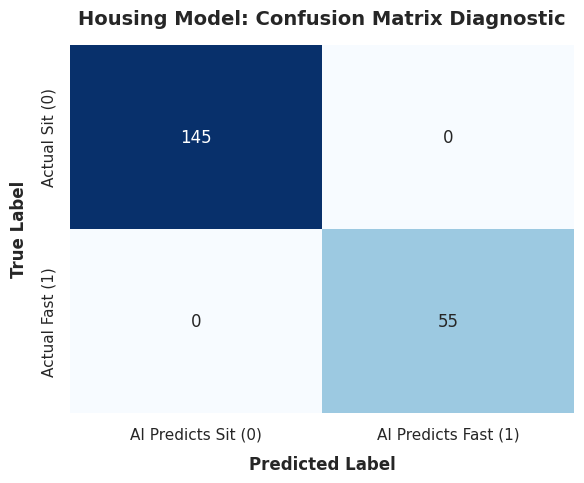

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. GENERATE THE MATHEMATICAL MATRIX
cm = confusion_matrix(true_labels, binary_predictions)

# 2. SETUP THE VISUAL PLOT
plt.figure(figsize=(6, 5))
sns.set_theme(style="whitegrid")

# Create a heatmap grid with text annotations inside
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['AI Predicts Sit (0)', 'AI Predicts Fast (1)'],
            yticklabels=['Actual Sit (0)', 'Actual Fast (1)'])

plt.title('Housing Model: Confusion Matrix Diagnostic', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Label', fontsize=12, fontweight='bold', labelpad=10)
plt.tight_layout()
plt.show()

Epoch 02/20 | Train Loss: 0.2331 | Val Loss: 0.3112
Epoch 04/20 | Train Loss: 0.2101 | Val Loss: 0.2739
Epoch 06/20 | Train Loss: 0.2282 | Val Loss: 0.2361
Epoch 08/20 | Train Loss: 0.2055 | Val Loss: 0.2375
Epoch 10/20 | Train Loss: 0.1941 | Val Loss: 0.2468
Epoch 12/20 | Train Loss: 0.1948 | Val Loss: 0.2328
Epoch 14/20 | Train Loss: 0.2002 | Val Loss: 0.2414
Epoch 16/20 | Train Loss: 0.1877 | Val Loss: 0.2791
Epoch 18/20 | Train Loss: 0.1939 | Val Loss: 0.2406
Epoch 20/20 | Train Loss: 0.1882 | Val Loss: 0.2685


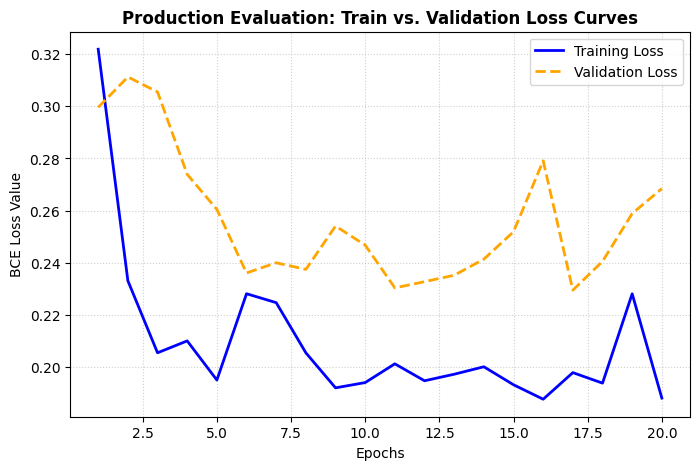

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. GENERATE NOISY REAL-WORLD STYLE DATA
np.random.seed(42)
num_samples = 1200

sq_ft = np.random.randint(1000, 4000, size=num_samples)
house_age = np.random.randint(1, 50, size=num_samples)
# Introducing a random noise factor to simulate unmeasured real-world chaos
noise = np.random.normal(0, 5, size=num_samples)

# Base Decision: Young homes generally sell fast, but noise scrambles the border cases
sell_fast = ((house_age + noise < 22)).astype(int)

df = pd.DataFrame({'sq_ft': sq_ft, 'house_age': house_age, 'sell_fast': sell_fast})

# Preprocess
X_data = df[['sq_ft', 'house_age']].values
y_data = df[['sell_fast']].values

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.20, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)

# 2. DEFINE MODEL
class TunableClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

model = TunableClassifier().to(device)
criterion = nn.BCELoss()

# ==========================================
# HYPERPARAMETER TUNING DIAL: LEARNING RATE
# Try switching this from 0.1 to 0.001 later to see the performance change!
# ==========================================
chosen_lr = 0.05
optimizer = optim.Adam(model.parameters(), lr=chosen_lr)

# Lists to store metrics for Production Evaluation plotting
train_losses = []
val_losses = []

# 3. TRAINING & EVALUATION LOOP
for epoch in range(1, 21):
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * batch_X.size(0)

    # Calculate average train loss for this epoch
    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    # Production Evaluation: Evaluate on unseen validation data
    model.eval()
    with torch.no_grad():
        val_preds = model(X_test_tensor)
        epoch_val_loss = criterion(val_preds, y_test_tensor).item()

    # Save values for plotting
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:02d}/20 | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

# 4. PLOT PRODUCTION EVALUATION CURVES
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, 21), val_losses, label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.title('Production Evaluation: Train vs. Validation Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('BCE Loss Value', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()